# Minimal Working Example

In [1]:
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
from chess_eval.constants import *
from chess_eval import DataManager, ModelManager, MetricsManager
from chess_eval import FEATURE_TRANSFORMERS

In [4]:
dm = DataManager(
    filepath=DATASET_FILE,
    read_size=1_000_000,
    sample_size=100_000,
    transformers=FEATURE_TRANSFORMERS,
)

In [5]:
model = GradientBoostingRegressor(
    loss="huber",
    learning_rate=0.03,
    n_estimators=1000,
    max_depth=5,
    subsample=0.8,
    max_features="sqrt",
    random_state=42
)

mm_gb = ModelManager(model, dm)

In [6]:
mm_gb.fit()
mm_gb.predict()

array([-89.33329187, -55.29565046, -15.32764936, ...,  -4.38905093,
       -17.06091055, 221.09122314], shape=(20000,))

MSE: 40079.602842350214
Sign accuracy: 0.6655
White winning recall: 0.8298747429426061
Black winning recall: 0.6340486409155937
Draw recall: 0.0
Centipawn ±200 accuracy: 0.8167
R2: 0.3251261872648088
R2 adjusted: 0.323332929866084
Spearman rank correlation: 0.5697392400049283


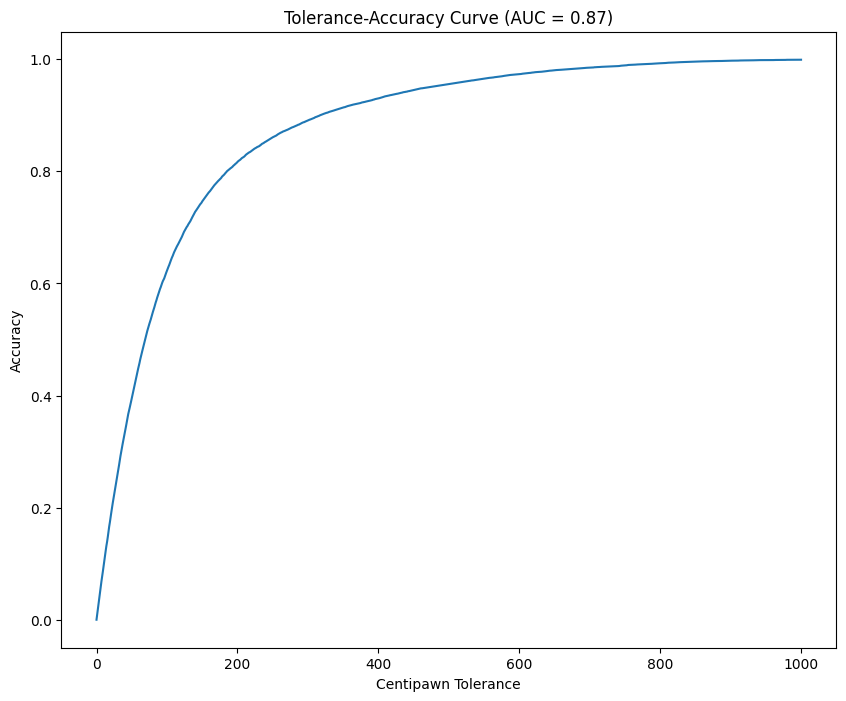

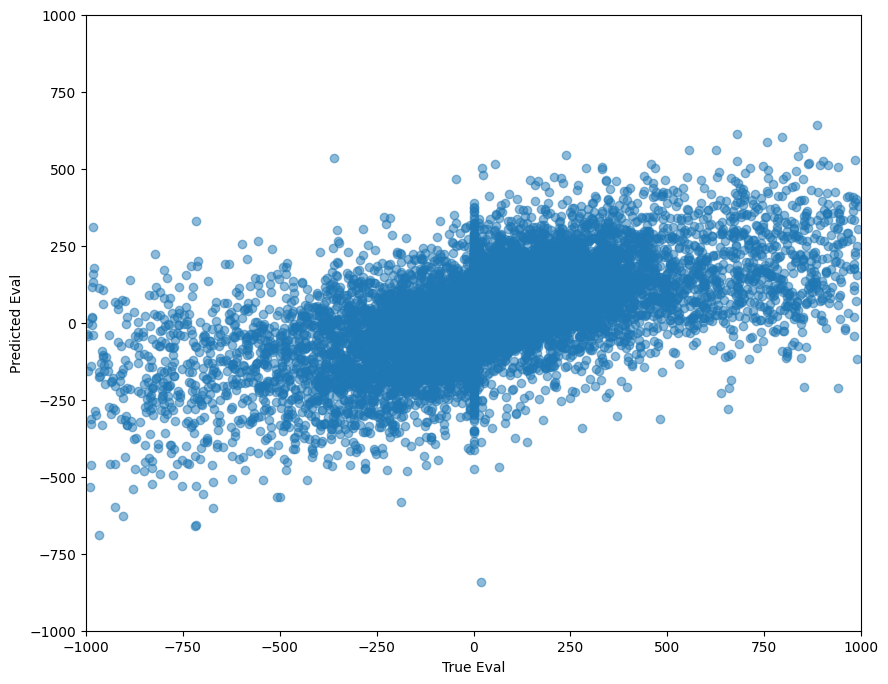

In [7]:
metm = MetricsManager(mm_gb)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()